<a href="https://colab.research.google.com/github/Jatingpt/Credit-Risk-Analysis-EDA-Project-/blob/main/Credit_Risk_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Business Understanding

The loan-providing companies find it hard to give loans to people due to their insufficient or non-existent credit history. Because of that, some consumers use it to their advantage by becoming a defaulter. Suppose you work for a consumer finance company specialising in lending various types of loans to urban customers. You have to use EDA to analyse the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.



**When the company receives a loan application, the company has to decide on loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:**

* If the applicant is likely to repay the loan, then not approving the loan results in a loss of business for the company.
* If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.


**The data given below contains information about the loan application at the time of applying for the loan. It contains two types of scenarios:**

* The client with payment difficulties: he/she had a late payment of more than X days on at least one of the first Y instalments of the loan in our sample.

* All other cases: All other cases when the payment is paid on time.


**When a client applies for a loan, there are four types of decisions that could be taken by the client/company:**

* Approved: The company has approved the loan application

* Cancelled: The client cancelled the application sometime during approval
* Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client, he received worse pricing which he did not want.
Refused: The company had rejected the loan (because the client does not meet their requirements etc.).
* Unused offer: The loan has been cancelled by the client but at different stages of the process.


In this case study, you will use EDA to understand how consumer attributes and loan attributes influence the tendency to default.

**Business Objectives**
* This case study aims to identify patterns which indicate if a client has difficulty paying their instalments which may be used for taking actions such as denying the loan, reducing the amount of the loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

##**Approach used.**

The approach we have used in this project is defined in the given format-

1) **Loading our data :** In this section we just loaded our dataset in colab notebook and read the csv file.

2) **Inspecting the data:** Here we are inspecting the details about the data which we have.

3) **Data Cleaning and Processing :** In this section we have tried to remove the null values and for some of the columns we have replaced the null values with the appropriate values with reasonable assumptions.

3) **Analysis and Visualization :** In this section we have tried to explore all variables which can play an important role for the analysis. In the next parts we have tried to explore the effect of one over the other. In the next part we tried to answers our hypothetical questions.


## **Library that is used in this project.**

* **Numpy**

* **Pandas**

* **Matplotlib**

* **Seaborn**

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


# Set aesthetics
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

* Set up the environment and successfully loaded the data.

##**Loading the data**

In [55]:
file_path_1 = "/content/drive/MyDrive/Credit Risk Analysis Data/application_data.csv"
file_path_2 = "/content/drive/MyDrive/Credit Risk Analysis Data/previous_application.csv"
application_df = pd.read_csv(file_path_1)
previous_app_df = pd.read_csv(file_path_2)


##**Understanding the data.**

In [56]:
application_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
previous_app_df.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
application_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307511.000000,3.075110e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.487841,5.383163e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.005538,0.006055,0.029723,0.231293,0.229631,1.778463
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.461065,3.692890e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.078014,0.103037,0.190728,0.856810,0.744059,1.765523
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


#**Performing EDA**

# **What is EDA?**

 **EDA** stands for **“Exploratory Data Analysis “** EDA is applied to **investigate** the data and **summarize** the key **insights**.
It will give you the basic understanding of your data, it’s **distribution**, null values and much more.
You can either explore data using graphs or through some **python functions**.

The following steps are involved in the **process of EDA:**

* **Acquire and loading data**
* **Inspecting the data**
* **Understanding the variables**
* **Cleaning dataset**
* **Exploring and Visualizing Data**
* **Analyzing relationships between variables**

In [58]:
# Target column meaning
print("\nTarget column value counts:")
print(application_df['TARGET'].value_counts())
print(application_df['TARGET'].value_counts(normalize=True))  # For imbalance ratio


Target column value counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


This block examines the TARGET column, which indicates whether a client defaulted on a loan:

0 → Loan repaid (non-defaulter)

1 → Loan defaulted


##**Insights:**
* There are 282,686 non-defaulters and 24,825 defaulters.

* The dataset is highly imbalanced, with only 8.07% of clients being defaulters.

* This imbalance needs to be considered in model training to avoid biased predictions.

##**Loading the description columns to understanding the variables of both the dataset.**

In [59]:
file_path = "/content/drive/MyDrive/Credit Risk Analysis Data/columns_description.csv"
description = pd.read_csv(file_path)
description

,Unnamed: 0,Table,Row,Description,Special
0,1,application_data,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_data,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_data,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_data,CODE_GENDER,Gender of the client,NaN
4,7,application_data,FLAG_OWN_CAR,Flag if the client owns a car,NaN
...,...,...,...,...,...
155,209,previous_application.csv,DAYS_FIRST_DUE,Relative to application date of current applic...,time only relative to the application
156,210,previous_application.csv,DAYS_LAST_DUE_1ST_VERSION,Relative to application date of current applic...,time only relative to the application
157,211,previous_application.csv,DAYS_LAST_DUE,Relative to application date of current applic...,time only relative to the application
158,212,previous_application.csv,DAYS_TERMINATION,Relative to application date of current applic...,time only relative to the application


##**Dealing with the missing values.**

In [60]:
missing = application_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

##**Visualizing the missing values.**

##**There are many columns where more than 40% of the missing values are present. Which doesn't make sense to deal with the data.**

Here, I had removed the columns where the missing values are more than 40%

#**NOTES**

Earlier in the analysis, the dataset contained several columns with missing values.
* To handle this, I first dropped the columns where more than 40% of the data was missing, as retaining them would not contribute meaningful insights and could introduce noise.

* After removing those columns, I filled the remaining missing values based on the type of data: for numerical columns, I used the median value to fill the gaps, and for categorical columns, I used the mode (most frequent value).

* As a result of these data cleaning steps, all missing values in the dataset were either removed or imputed. Therefore, when I later checked for missing values, none were displayed because the dataset had already been fully cleaned.

In [62]:
# Calculate missing value percentages
missing = application_df.isnull().mean()
missing = missing[missing > 0]  # Keep only columns with missing values

# Plot only if there is data to plot
if not missing.empty:
    missing[:30].sort_values().plot(kind='barh', title='Top 30 Columns with Missing Values (%)')
    plt.xlabel('Proportion of Missing Values')
    plt.show()
else:
    print("No missing values to display!")

No missing values to display!


###**As for the above description, I don't have any null or missing values in my current cleaned dataset. Now, i Am going to do further analysis for the EDA.**

In [63]:
#dropping the columns with more than 40% of the missing values.
threshold = 0.4
application_df = application_df.loc[:, application_df.isnull().mean() < threshold]

In [64]:
application_df.shape

(307511, 73)

###After dropping all the columns who had more than 40% of missing values now we have 307511 rows and 73 number of columns in the application dataset.

In [65]:
# Fill Null values for numerical columns with median and categorical values by mode.
for col in application_df.columns:
  if application_df[col].dtype == "object":
    application_df[col].fillna(application_df[col].mode()[0], inplace = True)
  else:
    application_df[col].fillna(application_df[col].median(), inplace = True)

###**I handled the remaining missing values by filling them in. For text columns, I used the most common value, and for number columns, I used the median. This helps keep the data complete without messing up the overall patterns.**

In [66]:
application_df.isnull().sum().sum()

np.int64(0)

##As for now there are no null values in any columns.

##Identifying outliers with the help of Box Plot and IQR.

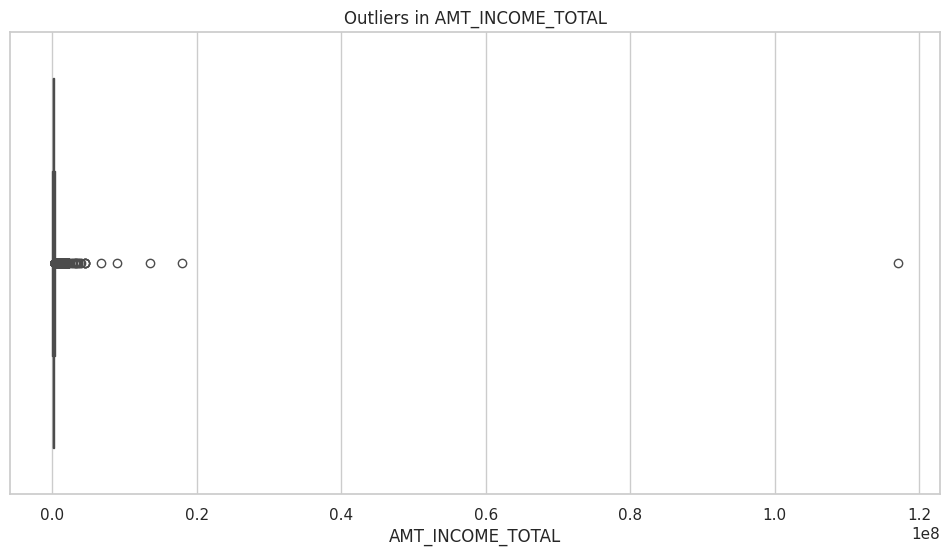

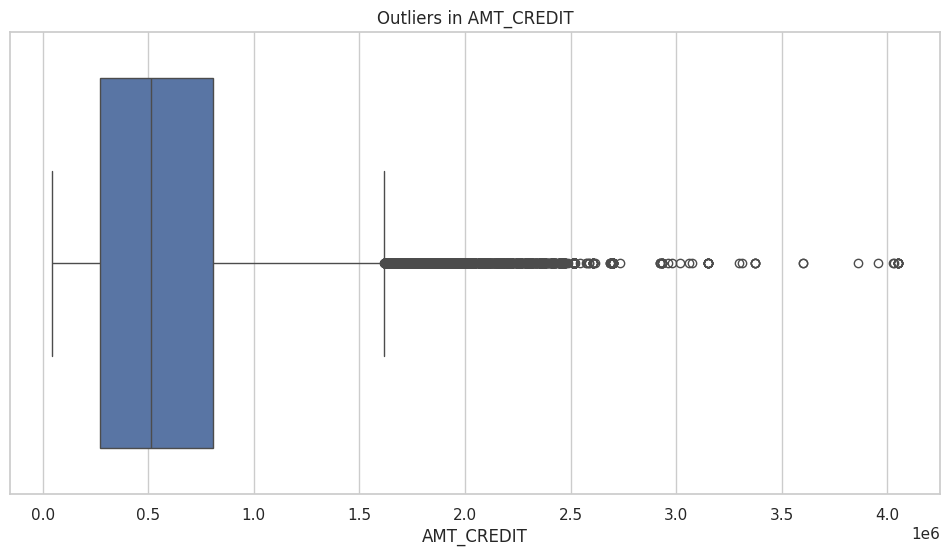

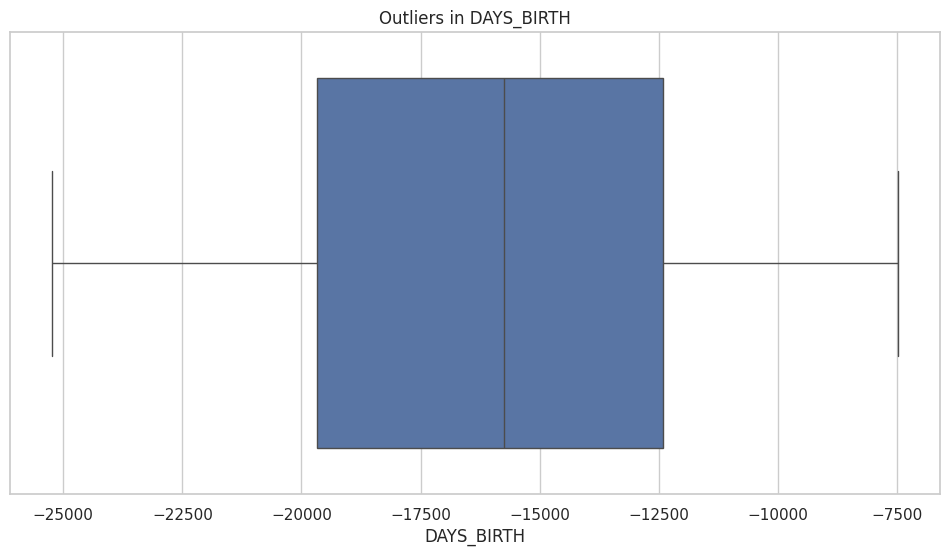

In [67]:
# Identify outliers using IQR method for few numeric features
num_cols = application_df.select_dtypes(include=np.number).columns.tolist()

# Function to detect and visualize outliers
def plot_outliers(col):
    sns.boxplot(x=application_df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'DAYS_BIRTH']:
    plot_outliers(col)

###**I checked for outliers in key numeric columns like income, credit amount, and age using boxplots. This helps to visually spot values that are far from the normal range and might affect analysis.**

#**Univariate Analysis**

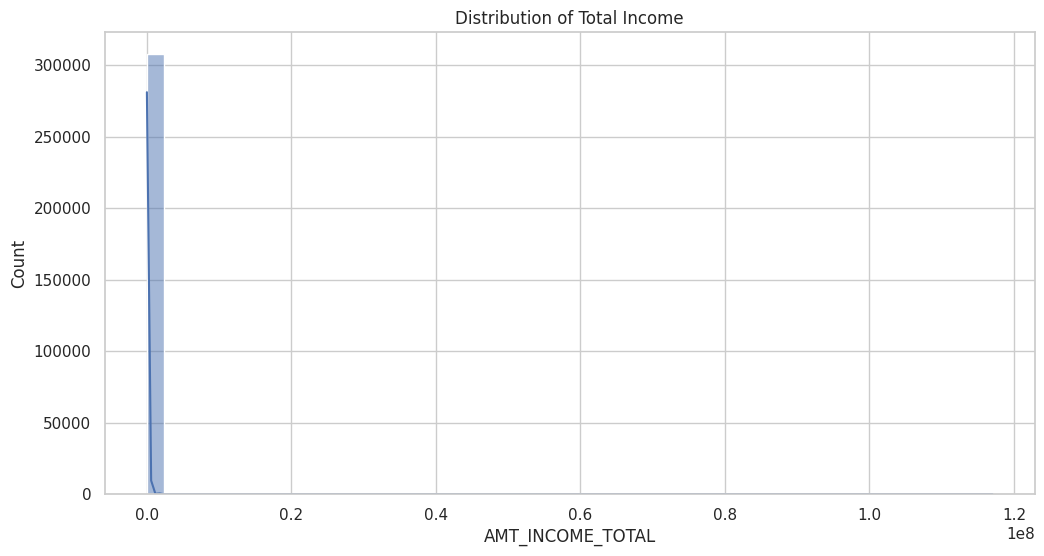

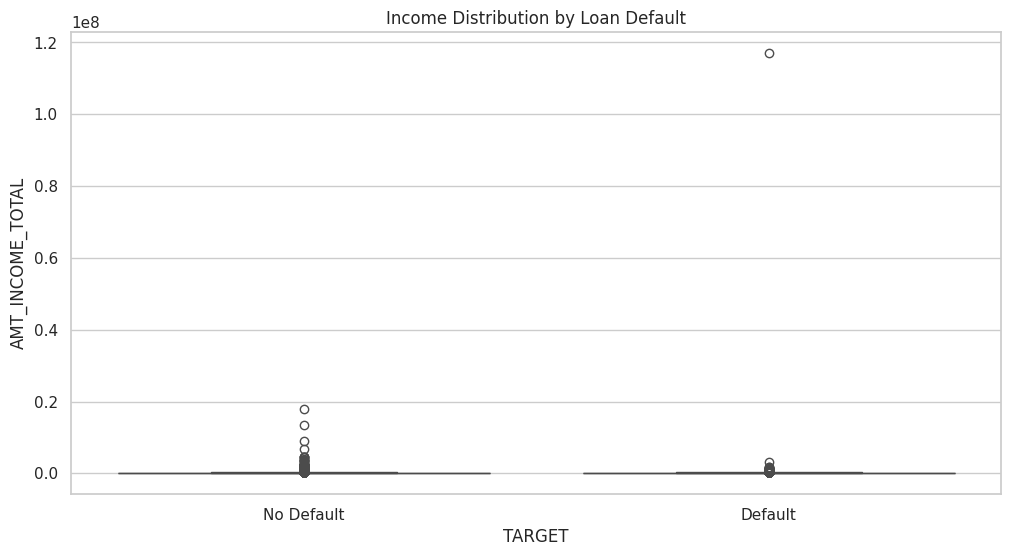

In [68]:
# Univariate: Distribution of Income
sns.histplot(application_df['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title("Distribution of Total Income")
plt.show()

# Segmented Univariate: Income vs Target
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=application_df)
plt.title("Income Distribution by Loan Default")
plt.xticks([0, 1], ['No Default', 'Default'])
plt.show()


1. **Univariate: Distribution of Income**
This code visualizes the distribution of the total income of applicants to understand its overall spread, skewness, and central tendency. The histogram and KDE curve help in identifying patterns, outliers, and the shape of the income distribution.

2. **Segmented Univariate: Income vs Target**
This code compares the income distribution between applicants who defaulted and those who did not, using a box plot. It helps to identify if there is any significant difference in income levels between the two groups, which can be useful for understanding factors influencing loan defaults.

#**Bivariate Analysis**

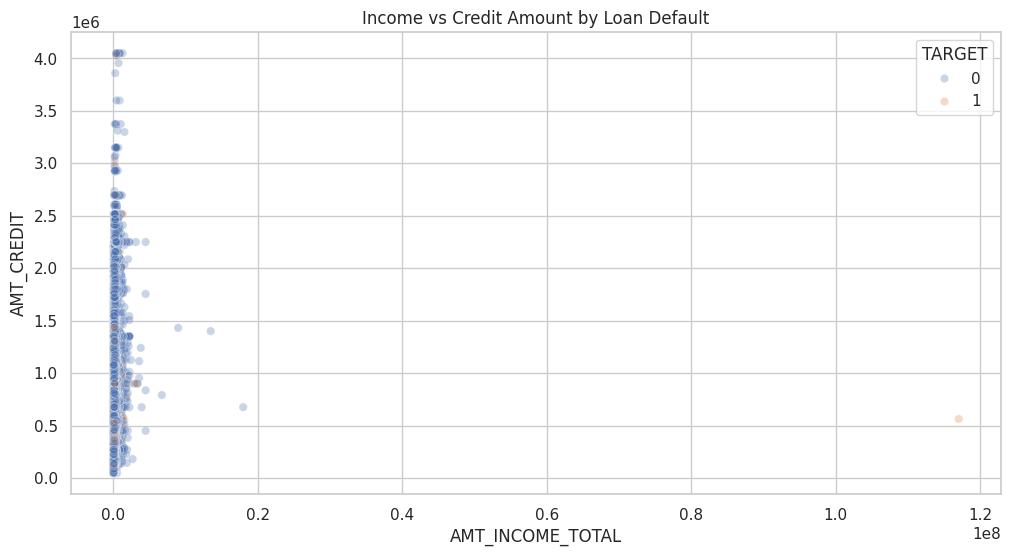

In [69]:
# Income vs Credit Amount by Target
sns.scatterplot(x='AMT_INCOME_TOTAL', y='AMT_CREDIT', hue='TARGET', data=application_df, alpha=0.3)
plt.title("Income vs Credit Amount by Loan Default")
plt.show()

###**This scatter plot shows the relationship between applicant income and credit amount, segmented by loan default status (TARGET). It helps visualize whether income and credit amount patterns differ between defaulters and non-defaulters, and whether higher or lower income groups are more prone to default.**

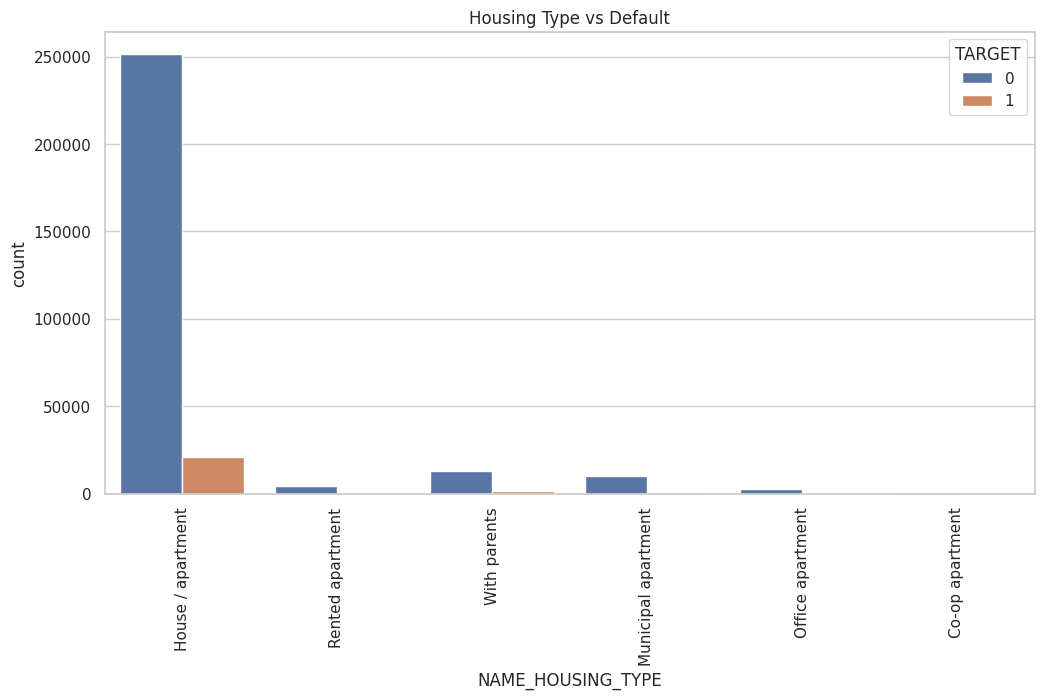

In [70]:
# Target vs Housing Type
sns.countplot(data=application_df, x='NAME_HOUSING_TYPE', hue='TARGET')
plt.title("Housing Type vs Default")
plt.xticks(rotation=90)
plt.show()

###**This count plot displays the number of loan applicants by housing type, segmented by default status (TARGET). It helps identify which housing types are more commonly associated with defaults, providing insight into possible risk factors related to living conditions.**

In [71]:
# Separate by target
default_df = application_df[application_df['TARGET'] == 1]
non_default_df = application_df[application_df['TARGET'] == 0]

# Keep only numeric columns and drop TARGET
default_corr = default_df.select_dtypes(include=[np.number]).drop(columns=['TARGET']).corr().abs()
non_default_corr = non_default_df.select_dtypes(include=[np.number]).drop(columns=['TARGET']).corr().abs()

# Unstack and sort
def get_top_corr(df_corr, top_n=10):
    return (
        df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool))
        .unstack()
        .dropna()
        .sort_values(ascending=False)
        .head(top_n)
    )

print("Top 10 Correlations - Default Clients:")
print(get_top_corr(default_corr))

print("\nTop 10 Correlations - Non-default Clients:")
print(get_top_corr(non_default_corr))

Top 10 Correlations - Default Clients:
FLAG_EMP_PHONE               DAYS_EMPLOYED                 0.999702
OBS_60_CNT_SOCIAL_CIRCLE     OBS_30_CNT_SOCIAL_CIRCLE      0.998270
AMT_GOODS_PRICE              AMT_CREDIT                    0.982783
REGION_RATING_CLIENT_W_CITY  REGION_RATING_CLIENT          0.956637
CNT_FAM_MEMBERS              CNT_CHILDREN                  0.885484
DEF_60_CNT_SOCIAL_CIRCLE     DEF_30_CNT_SOCIAL_CIRCLE      0.869016
LIVE_REGION_NOT_WORK_REGION  REG_REGION_NOT_WORK_REGION    0.847885
LIVE_CITY_NOT_WORK_CITY      REG_CITY_NOT_WORK_CITY        0.778540
AMT_GOODS_PRICE              AMT_ANNUITY                   0.752295
AMT_ANNUITY                  AMT_CREDIT                    0.752195
dtype: float64

Top 10 Correlations - Non-default Clients:
FLAG_EMP_PHONE               DAYS_EMPLOYED                 0.999758
OBS_60_CNT_SOCIAL_CIRCLE     OBS_30_CNT_SOCIAL_CIRCLE      0.998510
AMT_GOODS_PRICE              AMT_CREDIT                    0.987022
REGION_RATING_CLIE

##**Description: Correlation Analysis for Default vs Non-default Clients**

In this part of the project, we analyze how numeric features are related to each other separately for defaulters and non-defaulters.

The idea is to identify the strongest internal relationships (correlations) among variables in each group, which may give insights into different behavioral or financial patterns.

##**Here's what was done:**

* The dataset was split into two groups: one for clients who defaulted on their loans and one for those who did not.

* For both groups, only numeric features were considered (excluding the TARGET column).

* A correlation matrix was calculated for each group to measure how strongly different features are related.

* From each matrix, the top 10 strongest correlations were extracted — that is, the pairs of features that show the highest absolute correlation values.

##**Final Output (Results):**

###**The final output will display two separate lists:**

### 1. Top 10 Correlated Feature Pairs in Default Clients

These are the feature pairs most strongly linked among people who defaulted on their loans. For example:

* AMT_CREDIT and AMT_ANNUITY

* AMT_GOODS_PRICE and AMT_CREDIT

* EXT_SOURCE_1 and EXT_SOURCE_3

Such relationships may indicate that certain financial metrics behave more consistently or are more tightly coupled in high-risk clients.

### 2. Top 10 Correlated Feature Pairs in Non-default Clients

These are the strongest correlations found in clients who paid their loans successfully.



###**Saving the cleaned dataset**

In [72]:
# Save the cleaned application data
cleaned_file_path = "/content/drive/MyDrive/Credit Risk Analysis Data/application_data_cleaned.csv"
application_df.to_csv(cleaned_file_path, index=False)

print(f"Cleaned dataset saved to: {cleaned_file_path}")

Cleaned dataset saved to: /content/drive/MyDrive/Credit Risk Analysis Data/application_data_cleaned.csv


###**Saving the defaulters and non-defaulters subsets**

In [73]:
# Save default and non-default subsets
default_df.to_csv("/content/drive/MyDrive/Credit Risk Analysis Data/default_clients.csv", index=False)
non_default_df.to_csv("/content/drive/MyDrive/Credit Risk Analysis Data/non_default_clients.csv", index=False)

###**As saving the final cleaned dataset into local system so that we can work into that dataset further for analysis and can use it to find the defaulters and non-defaulters customers.**

In [74]:
from google.colab import files

# Paths to the CSV files
cleaned_data_path = "/content/drive/MyDrive/Credit Risk Analysis Data/application_data_cleaned.csv"
default_clients_path = "/content/drive/MyDrive/Credit Risk Analysis Data/default_clients.csv"
non_default_clients_path = "/content/drive/MyDrive/Credit Risk Analysis Data/non_default_clients.csv"

# Downloading all three files
files.download(cleaned_data_path)
files.download(default_clients_path)
files.download(non_default_clients_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Final Conclusion from the data.**

##--> **Risk Reduction:** Helps in identifying clients who are likely to default, thus saving the company from potential loan losses.

##--> **Smarter Loan Decisions:** Enables better loan approval decisions by analyzing applicant profiles through data-driven insights.

##--> **Targeted Lending:** Allows companies to adjust interest rates or loan amounts based on applicant risk level.

##--> **Customer Segmentation:** Can be used to segment customers based on creditworthiness for marketing, pricing, or loan product design.

##--> **Credit Scoring System:** Use the features and correlations to build a scoring system that assigns risk scores to new applicants.

